# Análisis del impacto educacional del uso de IA

In [77]:
import os
import math
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
def plot_cat_distribution(df, cat_cols, max_cols=3, palette="Set2"):
    """
    Crea un multiplot adaptativo mostrando la proporción de las categorías 
    para una lista de columnas de un DataFrame de Polars.
    
    Parámetros:
    - df: DataFrame de Polars.
    - cat_cols: Lista de strings con los nombres de las columnas a graficar.
    - max_cols: Número máximo de gráficos por fila (por defecto 3).
    - palette: Paleta de colores de Seaborn a utilizar (por defecto "Set2").
    """
    
    n_vars = len(cat_cols)
    
    # Validación de seguridad
    if n_vars == 0:
        print("Aviso: La lista de columnas está vacía.")
        return

    # --- 1. CONFIGURACIÓN ADAPTATIVA ---
    n_cols_fig = min(n_vars, max_cols)
    n_rows_fig = math.ceil(n_vars / n_cols_fig) 

    # Ajustamos el tamaño de la figura dinámicamente
    fig, axes = plt.subplots(nrows=n_rows_fig, ncols=n_cols_fig, figsize=(6 * n_cols_fig, 5 * n_rows_fig))

    # Forzamos a que axes sea siempre un array 2D
    if n_rows_fig == 1 and n_cols_fig == 1:
        axes = np.array([[axes]])
    elif n_rows_fig == 1:
        axes = axes[None, :]
    elif n_cols_fig == 1:
        axes = axes[:, None]

    # --- 2. DIBUJAR LOS GRÁFICOS ---
    for i, col in enumerate(cat_cols):
        
        r = i // n_cols_fig
        c = i % n_cols_fig
        ax = axes[r, c]
        
        # Procesamiento con Polars y conversión a Pandas para Seaborn
        serie_str = df[col].fill_null("Nulo").cast(pl.String).to_pandas()
        
        # Gráfico de proporciones
        sns.countplot(
            x=serie_str, 
            ax=ax, 
            palette=palette, 
            hue=serie_str, 
            legend=False, 
            stat='proportion'
        )
        
        # Configuración de títulos y etiquetas
        ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Proporción')
        ax.tick_params(axis='x', rotation=45)

    # --- 3. LIMPIEZA DE ESPACIOS VACÍOS ---
    total_blocks = n_rows_fig * n_cols_fig
    for i in range(n_vars, total_blocks):
        r = i // n_cols_fig
        c = i % n_cols_fig
        fig.delaxes(axes[r, c])

    # --- 4. RENDERIZADO ---
    plt.tight_layout()
    plt.show()

In [79]:
def plot_quant_distribution(df, quant_cols, max_cols=3, box_color="skyblue", hist_color="salmon"):
    """
    Crea un multiplot adaptativo mostrando un Boxplot y un Histograma (con proporciones)
    para una lista de columnas cuantitativas de un DataFrame de Polars.
    
    Parámetros:
    - df: DataFrame de Polars.
    - quant_cols: Lista de strings con los nombres de las columnas a graficar.
    - max_cols: Número máximo de columnas de variables por fila (por defecto 3).
    - box_color: Color para los boxplots (por defecto "skyblue").
    - hist_color: Color para los histogramas (por defecto "salmon").
    """
    n_vars = len(quant_cols)
    
    # Validación por si la lista viene vacía
    if n_vars == 0:
        print("Aviso: La lista de columnas cuantitativas está vacía.")
        return

    # --- 1. CONFIGURACIÓN ADAPTATIVA ---
    n_cols_fig = min(n_vars, max_cols)
    
    # Calculamos cuántas "filas de variables" necesitamos
    n_rows_vars = math.ceil(n_vars / n_cols_fig) 
    
    # Como cada variable usa 2 filas reales (boxplot + hist), multiplicamos por 2
    n_rows_fig = n_rows_vars * 2

    # Ajustamos el tamaño de la figura dinámicamente
    fig, axes = plt.subplots(nrows=n_rows_fig, ncols=n_cols_fig, figsize=(6 * n_cols_fig, 3 * n_rows_fig))

    # Forzamos a que axes sea siempre un array 2D
    if n_rows_fig == 2 and n_cols_fig == 1:
        axes = axes.reshape(2, 1)

    # --- 2. DIBUJAR LOS GRÁFICOS ---
    for i, col in enumerate(quant_cols):
        
        # Mágia matemática para encontrar la coordenada exacta
        r = (i // n_cols_fig) * 2  
        c = i % n_cols_fig         
        
        ax_box = axes[r, c]
        ax_hist = axes[r + 1, c] 
        
        # Compatibilidad Polars -> Pandas (limpiamos nulos para que el KDE no falle)
        serie_num = df[col].drop_nulls().to_pandas()
        
        # --- BOXPLOT ---
        sns.boxplot(x=serie_num, ax=ax_box, color=box_color)
        ax_box.set_title(col.upper(), fontsize=12, fontweight='bold')
        ax_box.set_xlabel('')
        
        # --- HISTOGRAMA ---
        sns.histplot(x=serie_num, kde=True, ax=ax_hist, color=hist_color, edgecolor="black", stat='proportion')
        ax_hist.set_title(col.upper(), fontsize=12, fontweight='bold')
        ax_hist.set_xlabel(col)
        ax_hist.set_ylabel('Proporción')

    # --- 3. LIMPIEZA DE ESPACIOS VACÍOS ---
    total_blocks = n_rows_vars * n_cols_fig
    for i in range(n_vars, total_blocks):
        r = (i // n_cols_fig) * 2
        c = i % n_cols_fig
        fig.delaxes(axes[r, c])
        fig.delaxes(axes[r + 1, c])

    # --- 4. RENDERIZADO ---
    plt.tight_layout()
    plt.show()

In [80]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

forms_data_filename = 'processed_pre_post_forms.parquet'
forms_data_path = os.path.join(project_path, 'data', 'forms', 'processed_data', forms_data_filename)

interactions_data_filename = 'interactions_processed_data.parquet'
interactions_data_path = os.path.join(project_path, 'data', 'interactions', 'processed_data', interactions_data_filename)

forms_df = pl.read_parquet(forms_data_path)
interactions_df = pl.read_parquet(interactions_data_path)

In [81]:
base_cols = ['id', 'centro', 'grupo']

metrics_pre_post = [
    'puntuacion_tc', 
    'puntuacion_ta', 
    'puntuacion_tc_retencion', 
    'puntuacion_tc_transferencia'
]

metrics_post = [
    'puntuacion_tcc_rel_post', 
    'puntuacion_tcc_int_post', 
    'puntuacion_tcc_ext_post', 
]

hake_metrics = [
    'puntuacion_tc_hake_gain', 
    'puntuacion_tc_retencion_hake_gain', 
    'puntuacion_tc_transferencia_hake_gain'
]

forms_cols_analysis = base_cols + hake_metrics + [
    f"{metric}{cat_suffix}_{period}"
    for period in ['pre', 'post']
    for cat_suffix in ['', '_cat']
    for metric in metrics_pre_post
] + metrics_post

forms_df = forms_df[forms_cols_analysis]

forms_interactions_df = forms_df.join(interactions_df, how='left', on='id')


---

## Vista de la tabla

In [82]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,i64,i64,bool,bool,bool,str,f64,str,bool
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.2,0.8,0.4,"""Medio""","""Bajo""","""Medio""","""Bajo""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.43,0.27,2,5,true,true,true,"""Lower_Intermediate""",1.5,"""Lower_Intermediate""",false
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,0.8,0.48,1.0,0.6,"""Alto""","""Medio""","""Alto""","""Medio""",1.0,0.55,1.0,1.0,"""Alto""","""Medio""","""Medio""","""Alto""",0.2,0.4,0.27,8,5,false,true,true,"""High""",1.625,"""Lower_Intermediate""",false
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.45,0.6,0.6,"""Medio""","""Medio""","""Bajo""","""Medio""",1.0,0.4,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.57,0.6,0.47,7,5,true,true,true,"""High""",2.571429,"""High""",true
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.666667,0.6,0.7,0.8,0.4,"""Medio""","""Alto""","""Medio""","""Bajo""",0.6,0.43,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Bajo""",0.63,0.53,0.63,0,5,false,false,true,"""Not_Used""",null,null,false
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,0.8,0.52,1.0,0.6,"""Alto""","""Alto""","""Alto""","""Medio""",0.9,0.6,1.0,0.8,"""Medio""","""Alto""","""Medio""","""Bajo""",0.9,0.3,0.27,0,5,false,false,true,"""Not_Used""",null,null,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,0.7,0.35,0.8,0.6,"""Medio""","""Bajo""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.63,0.47,0.43,3,5,true,true,true,"""Upper_Intermediate""",1.333333,"""Low""",false
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333333,0.5,0.52,0.6,0.4,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.7,0.6,0.8,0.6,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.53,0.2,2,5,false,true,true,"""Lower_Intermediate""",1.0,"""Low""",false
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,0.5,0.52,0.8,0.2,"""Bajo""","""Alto""","""Medio""","""Bajo""",0.6,0.58,0.4,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.93,0.27,0.33,4,5,false,true,true,"""Upper_Intermediate""",0.0,"""Not_Relevant""",false


---

## Valores únicos

In [83]:
for col in forms_interactions_df.columns:
    print(col.upper())
    display(forms_interactions_df[col].unique().to_list())
    print('-' * 100)

ID


['Laguna-zfa',
 'JoseGarciaNieto-4i2',
 'JoseGarciaNieto-5r5',
 'Laguna-6vh',
 'Laguna-yfr',
 'RamiroMaeztu-31d',
 'JesusMaria-nms',
 'RamiroMaeztu-x5e',
 'JesusMaria-iff',
 'RamiroMaeztu-8pr',
 'RamiroMaeztu-a28',
 'Laguna-uhu',
 'Laguna-c6j',
 'Laguna-bej',
 'RamiroMaeztu-5p9',
 'RamiroMaeztu-st5',
 'JoseGarciaNieto-nnx',
 'JesusMaria-a65',
 'JesusMaria-4e6',
 'RamiroMaeztu-59v',
 'RamiroMaeztu-9t2',
 'RamiroMaeztu-2rr',
 'RamiroMaeztu-8q1',
 'JesusMaria-l57',
 'RamiroMaeztu-86g',
 'JesusMaria-64o',
 'Laguna-uvx',
 'Laguna-gum',
 'JesusMaria-xpe',
 'Laguna-6m6',
 'RamiroMaeztu-ykt',
 'RamiroMaeztu-39p',
 'RamiroMaeztu-4ux',
 'RamiroMaeztu-lei',
 'JoseGarciaNieto-8k0',
 'RamiroMaeztu-4gj',
 'JoseGarciaNieto-wba',
 'JesusMaria-hs2',
 'JesusMaria-szt',
 'JesusMaria-ecq',
 'RamiroMaeztu-ks0',
 'JoseGarciaNieto-5zg',
 'JesusMaria-nre',
 'Laguna-2al',
 'Laguna-d9f',
 'Laguna-yno',
 'JoseGarciaNieto-033',
 'RamiroMaeztu-qjr',
 'JoseGarciaNieto-dh0',
 'RamiroMaeztu-404',
 'RamiroMaeztu-zhk',

----------------------------------------------------------------------------------------------------
CENTRO


['RamiroMaeztu', 'JesusMaria', 'Laguna', 'JoseGarciaNieto']

----------------------------------------------------------------------------------------------------
GRUPO


...

----------------------------------------------------------------------------------------------------
WSDI_CAT


['Lower_Intermediate',
 'Upper_Intermediate',
 None,
 'High',
 'Low',
 'Not_Relevant']

----------------------------------------------------------------------------------------------------
HIGH_QUALITY_USE


[False, True, None]

----------------------------------------------------------------------------------------------------


---

## Descripción general

In [84]:
forms_interactions_df.describe()

statistic,id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,91.0,91.0,85.0,91.0,91.0,"""91""",62.0,"""62""",91.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,100.0,100.0,106.0,100.0,100.0,"""100""",129.0,"""129""",100.0
"""mean""",null,null,null,0.312509,0.209424,0.417976,0.60733,0.438901,0.684817,0.529843,null,null,null,null,0.764921,0.504241,0.774869,0.754974,null,null,null,null,0.727016,0.403822,0.383194,2.516484,4.67033,0.505882,0.681319,0.934066,null,1.519886,null,0.197802
"""std""",null,null,null,0.632698,0.839663,0.507214,0.182234,0.128556,0.232447,0.218847,null,null,null,null,0.175843,0.117421,0.227103,0.207907,null,null,null,null,0.179405,0.215019,0.185973,2.583549,1.247709,null,null,null,null,0.547501,null,null
"""min""","""JesusMaria-1lv""","""JesusMaria""","""control""",-3.0,-4.0,-1.0,0.2,0.12,0.0,0.0,"""Alto""","""Alto""","""Alto""","""Alto""",0.1,0.15,0.0,0.0,"""Alto""","""Alto""","""Bajo""","""Alto""",0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,"""High""",0.0,"""High""",0.0
"""25%""",null,null,null,0.0,0.0,0.0,0.5,0.35,0.6,0.4,null,null,null,null,0.7,0.43,0.6,0.6,null,null,null,null,0.63,0.23,0.23,0.0,5.0,null,null,null,null,1.0,null,null
"""50%""",null,null,null,0.5,0.0,0.5,0.6,0.45,0.8,0.6,null,null,null,null,0.8,0.5,0.8,0.8,null,null,null,null,0.73,0.37,0.37,2.0,5.0,null,null,null,null,1.6,null,null
"""75%""",null,null,null,0.714286,1.0,0.8,0.7,0.52,0.8,0.6,null,null,null,null,0.9,0.6,1.0,1.0,null,null,null,null,0.87,0.53,0.5,4.0,5.0,null,null,null,null,2.0,null,null
"""max""","""RamiroMaeztu-zhk""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,1.0,0.7,1.0,1.0,"""Medio""","""Medio""","""Medio""","""Medio""",1.0,0.7,1.0,1.0,"""Medio""","""Medio""","""Medio""","""Bajo""",1.0,1.0,1.0,12.0,5.0,1.0,1.0,1.0,"""Upper_Intermediate""",3.0,"""Upper_Intermediate""",1.0


---

## Visualización distribuciones

In [85]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

### Variables de contexto

In [88]:
context_cols = ['centro', 'grupo']

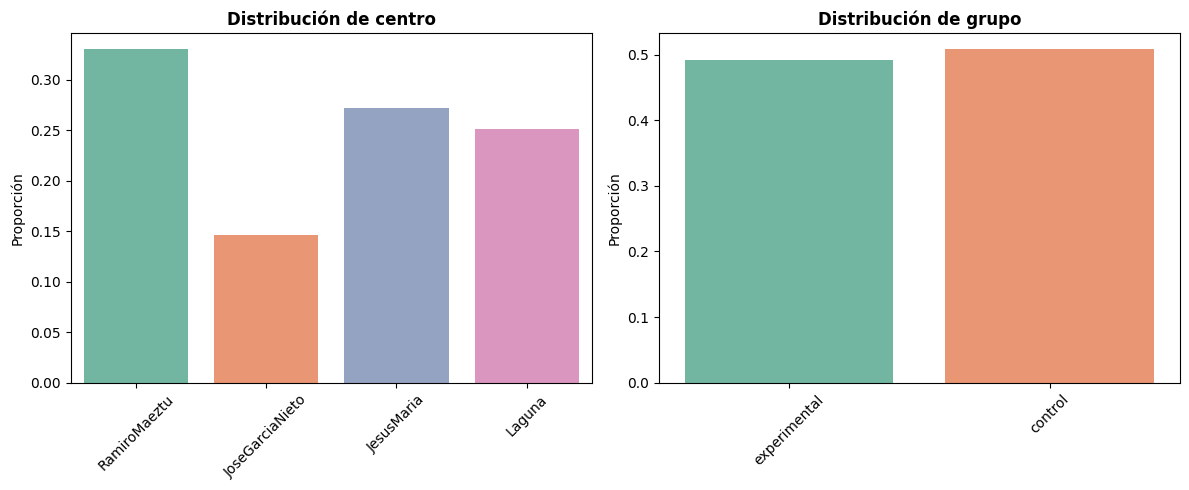

In [89]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = context_cols, 
    max_cols=3, 
    palette="Set2"
)

### Métricas Forms

In [90]:
forms_cols = [col for col in forms_interactions_df.columns if 'puntuacion' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

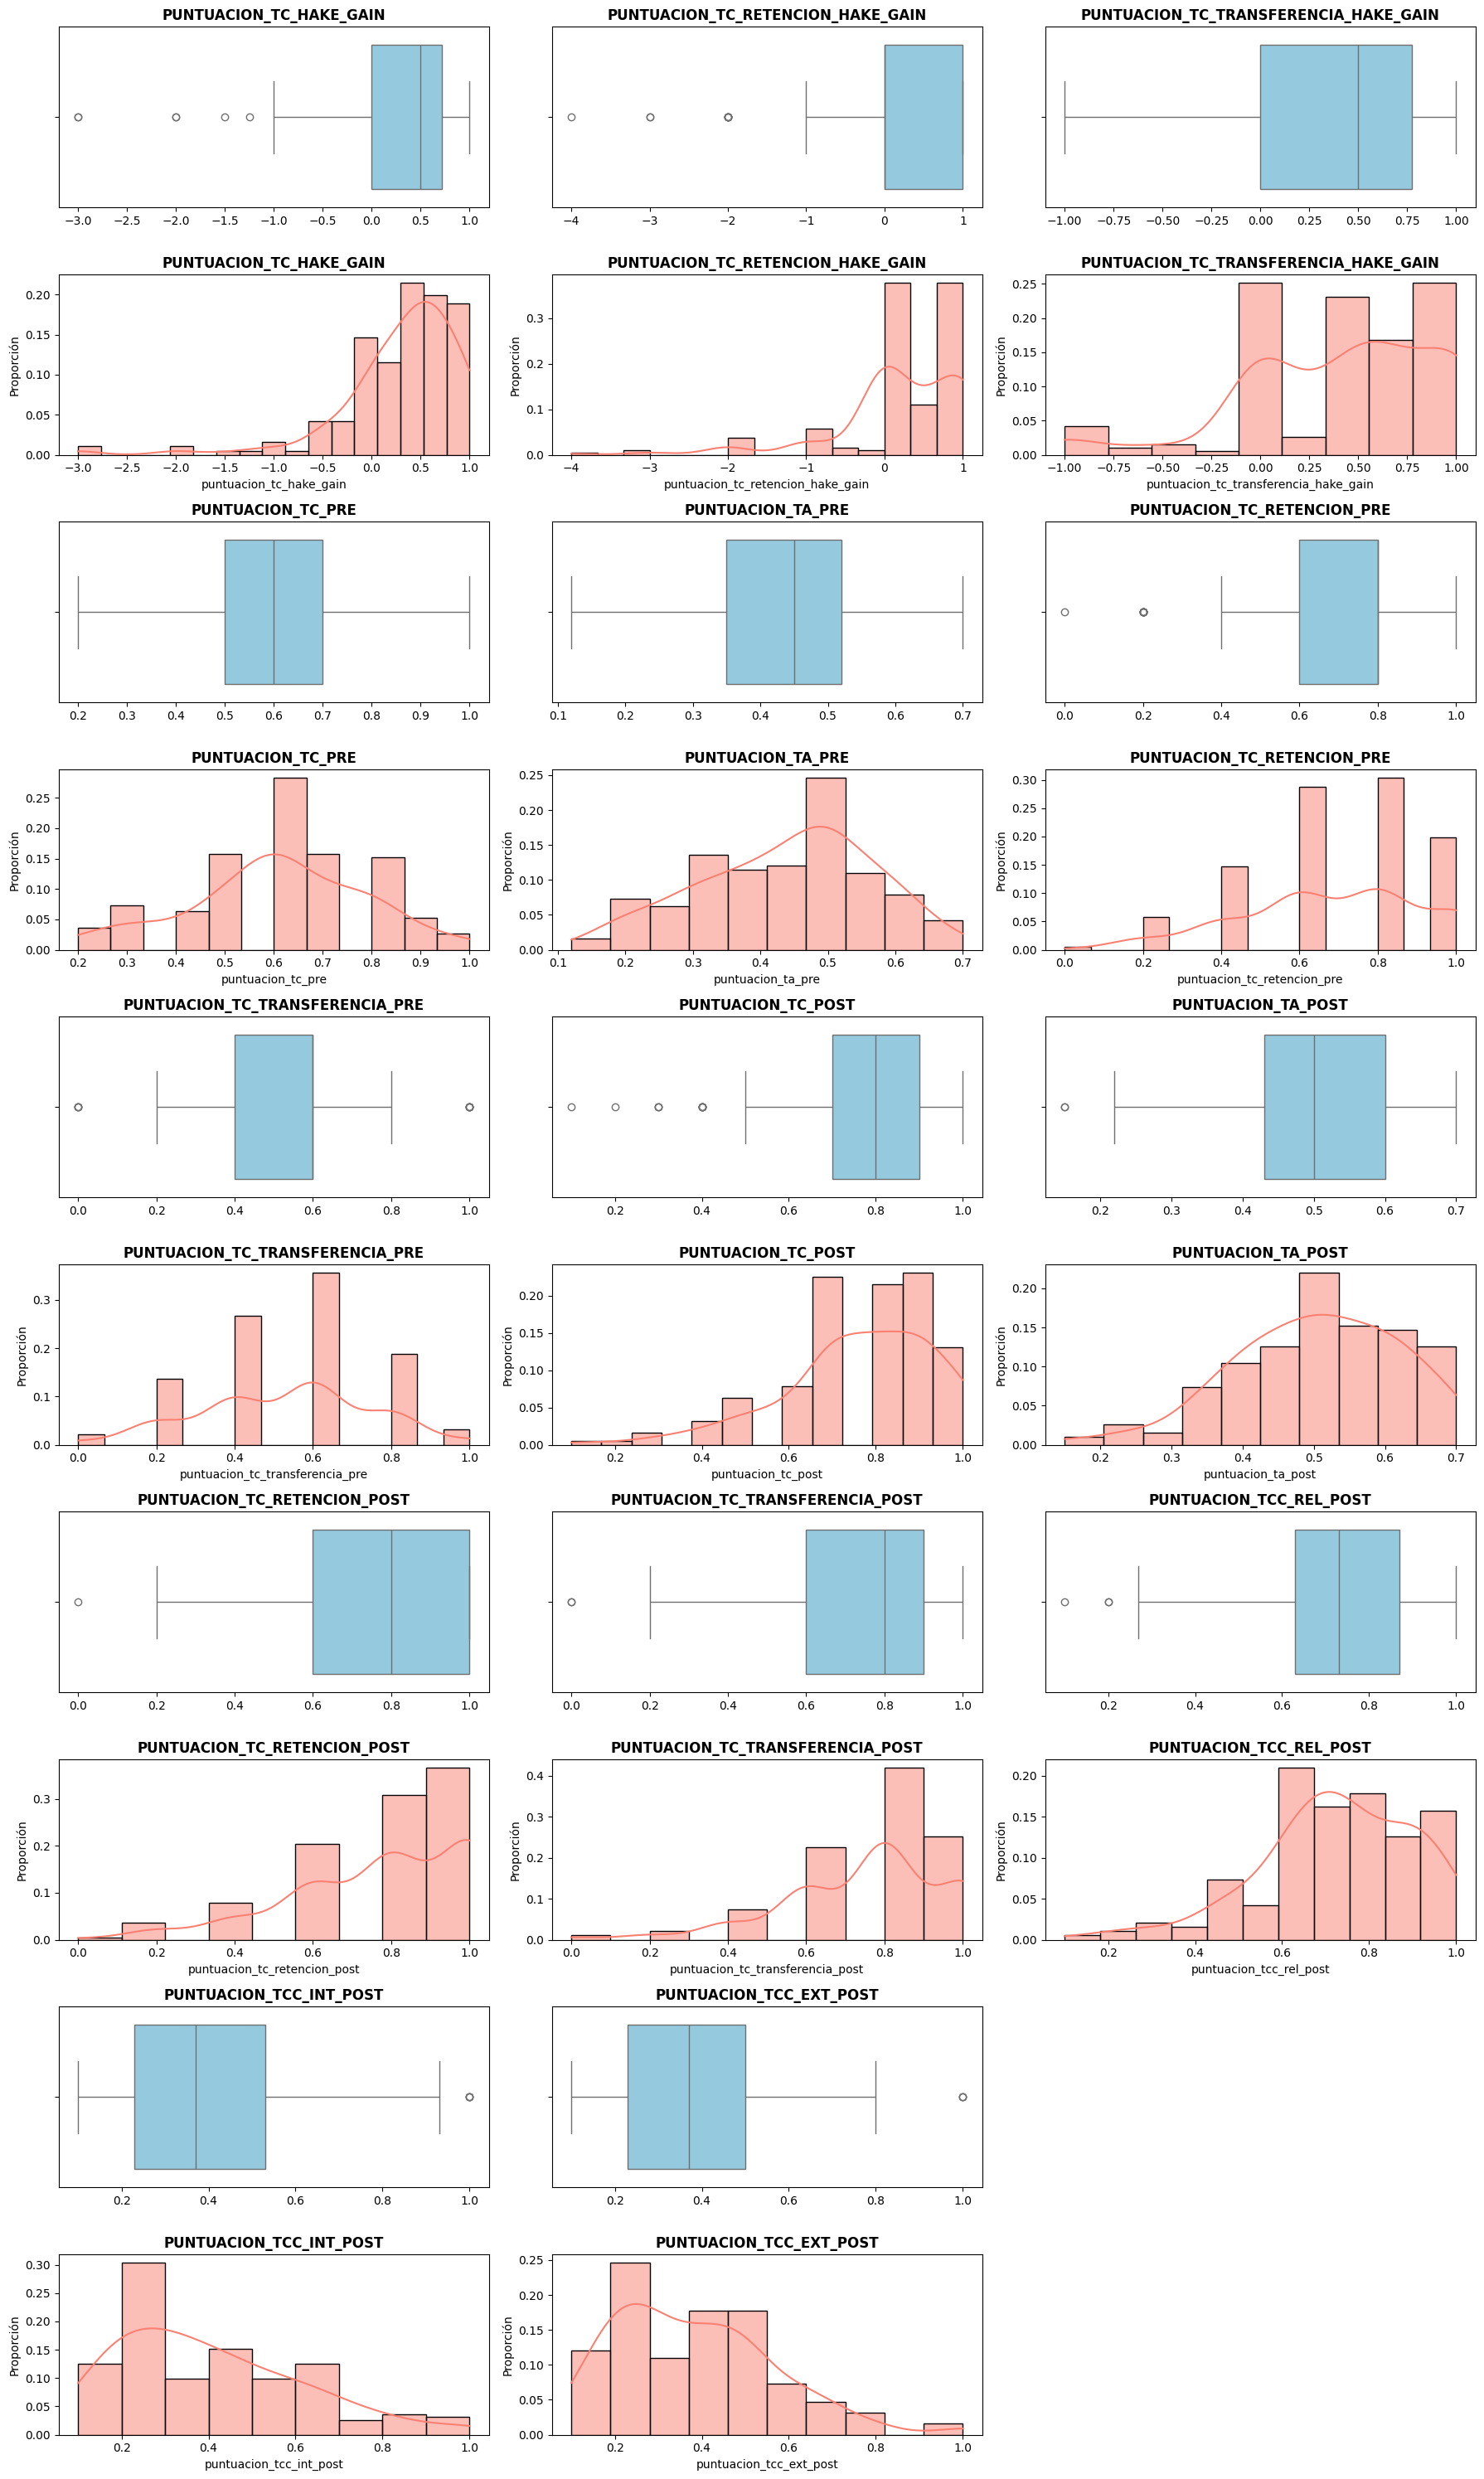

In [91]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = forms_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

### Métricas Herramienta

In [94]:
chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + ['id']]

chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

In [ ]:
plot_quant_distribution(
    df = forms_interactions_df.filter(pl.col('grupo') == 'experimental'), 
    cat_cols = chats_quant_cols, 
    max_cols=3, 
    palette="Set2"
)

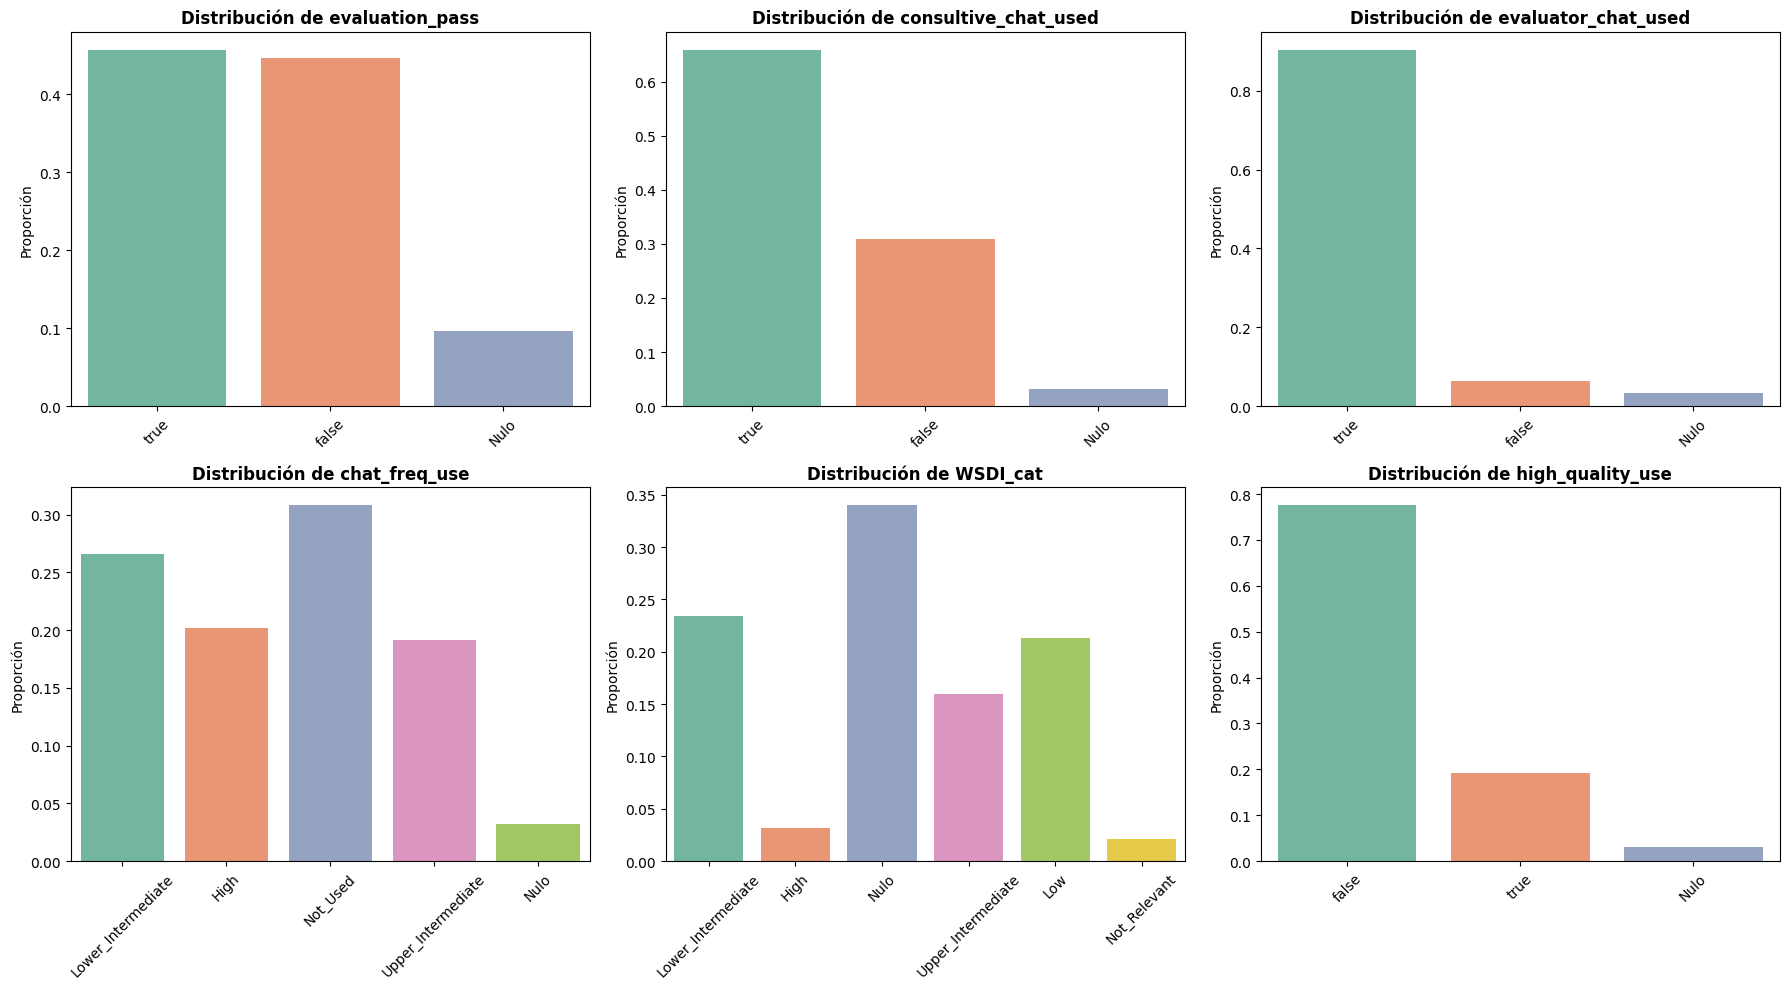

In [96]:
plot_cat_distribution(
    df = forms_interactions_df.filter(pl.col('grupo') == 'experimental'), 
    cat_cols = chats_cat_cols, 
    max_cols=3, 
    palette="Set2"
)

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [97]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""control""",97
"""experimental""",94


In [109]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
"""High""",19
null,100
"""Lower_Intermediate""",25
"""Not_Used""",29
"""Upper_Intermediate""",18


In [104]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [110]:
forms_interactions_df['grupo'].value_counts().filter(pl.col('grupo') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Cuales IDs?

Hay alguno de experimental con null en la herramienta? --> Cuales IDs?

In [111]:
forms_interactions_df.filter(
    pl.col('grupo') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,i64,i64,bool,bool,bool,str,f64,str,bool


In [112]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,i64,i64,bool,bool,bool,str,f64,str,bool
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,0.9,0.28,0.8,1.0,"""Alto""","""Bajo""","""Medio""","""Alto""",0.8,0.45,0.8,0.8,"""Medio""","""Bajo""","""Bajo""","""Bajo""",0.6,0.6,0.63,null,null,null,null,null,null,null,null,null
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,0.7,0.48,0.8,0.6,"""Medio""","""Medio""","""Medio""","""Medio""",0.7,0.6,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Bajo""",0.83,0.27,0.23,null,null,null,null,null,null,null,null,null
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.666667,0.6,0.45,0.8,0.4,"""Medio""","""Medio""","""Medio""","""Bajo""",0.1,0.48,0.2,0.0,"""Bajo""","""Medio""","""Bajo""","""Bajo""",0.6,0.63,0.6,null,null,null,null,null,null,null,null,null


---

In [51]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""control""",96
"""experimental""",95
null,1


In [52]:
forms_interactions_df.filter(pl.col('grupo').is_null())

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""Laguna-i9p""","""Laguna""",null,-0.2,0.0,-0.5,0.5,0.45,null,null,null,0.4,0.6,"""Bajo""","""Medio""",null,null,null,"""Bajo""","""Medio""",0.4,0.43,0.5,0.5,0.5,0.4,0.4,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null


In [53]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.2,null,null,null,0.8,0.4,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Bajo""",1.0,0.4,0.8,0.43,0.27,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Medio""","""Alto""",2,5,true,true,true,"""Lower_Intermediate""",1.5,"""Lower_Intermediate""",false
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,0.8,0.48,null,null,null,1.0,0.6,"""Alto""","""Medio""",null,null,null,"""Alto""","""Medio""",1.0,0.55,0.2,0.4,0.27,1.0,1.0,"""Alto""","""Medio""","""Bajo""","""Medio""","""Bajo""","""Medio""","""Alto""",8,5,false,true,true,"""High""",1.625,"""Lower_Intermediate""",false
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.45,null,null,null,0.6,0.6,"""Medio""","""Medio""",null,null,null,"""Bajo""","""Medio""",1.0,0.4,0.57,0.6,0.47,1.0,1.0,"""Alto""","""Bajo""","""Bajo""","""Alto""","""Medio""","""Medio""","""Alto""",7,5,true,true,true,"""High""",2.571429,"""High""",true
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.666667,0.6,0.7,null,null,null,0.8,0.4,"""Medio""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.6,0.43,0.63,0.53,0.63,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",0,5,false,false,true,"""Not_Used""",null,null,false
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,0.8,0.52,null,null,null,1.0,0.6,"""Alto""","""Alto""",null,null,null,"""Alto""","""Medio""",0.9,0.6,0.9,0.3,0.27,1.0,0.8,"""Medio""","""Alto""","""Alto""","""Medio""","""Bajo""","""Medio""","""Bajo""",0,5,false,false,true,"""Not_Used""",null,null,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,0.7,0.35,null,null,null,0.8,0.6,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Medio""",0.7,0.6,0.63,0.47,0.43,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Bajo""",3,5,true,true,true,"""Upper_Intermediate""",1.333333,"""Low""",false
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333333,0.5,0.52,null,null,null,0.6,0.4,"""Bajo""","""Alto""",null,null,null,"""Bajo""","""Bajo""",0.7,0.6,0.93,0.53,0.2,0.8,0.6,"""Bajo""","""Alto""","""Alto""","""Alto""","""Bajo""","""Bajo""","""Bajo""",2,5,false,true,true,"""Lower_Intermediate""",1.0,"""Low""",false
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,0.5,0.52,null,null,null,0.8,0.2,"""Bajo""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.6,0.58,0.93,0.27,0.33,0.4,0.8,"""Bajo""","""Alto""","""Alto""","""Bajo""","""Medio""","""Bajo""","""Bajo""",4,5,false,true,true,"""Upper_Intermediate""",0.0,"""Not_Relevant""",false


In [54]:
forms_interactions_df.group_by(['grupo', 'chat_freq_use']).agg(pl.len())

grupo,chat_freq_use,len
str,str,u32
"""experimental""","""Not_Used""",30
"""control""",null,96
null,null,1
"""experimental""",null,3
"""experimental""","""High""",19
"""experimental""","""Lower_Intermediate""",25
"""experimental""","""Upper_Intermediate""",18


In [55]:
forms_interactions_df.filter((pl.col('grupo') == 'experimental') & (pl.col('evaluation_answers_counts').is_null()))
# Hay que ver que hacer con estos 3 que pertenecen al experimental pero que no se han registrados sus datos de interacción con la herramienta

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,0.9,0.28,null,null,null,0.8,1.0,"""Alto""","""Bajo""",null,null,null,"""Medio""","""Alto""",0.8,0.45,0.6,0.6,0.63,0.8,0.8,"""Medio""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,0.7,0.48,null,null,null,0.8,0.6,"""Medio""","""Medio""",null,null,null,"""Medio""","""Medio""",0.7,0.6,0.83,0.27,0.23,0.6,0.8,"""Bajo""","""Alto""","""Medio""","""Bajo""","""Bajo""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.666667,0.6,0.45,null,null,null,0.8,0.4,"""Medio""","""Medio""",null,null,null,"""Medio""","""Bajo""",0.1,0.48,0.6,0.63,0.6,0.2,0.0,"""Bajo""","""Medio""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",null,null,null,null,null,null,null,null,null


In [56]:
forms_interactions_df.filter((pl.col('id') == 'RamiroMaeztu-kya'))

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""RamiroMaeztu-kya""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.5,0.4,null,null,null,0.8,0.2,"""Bajo""","""Bajo""",null,null,null,"""Medio""","""Bajo""",1.0,0.45,0.93,0.2,0.37,1.0,1.0,"""Alto""","""Bajo""","""Alto""","""Bajo""","""Medio""","""Medio""","""Alto""",0,5,true,false,true,"""Not_Used""",null,null,false


In [57]:
forms_interactions_df.filter((pl.col('grupo') == 'experimental'))

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.2,null,null,null,0.8,0.4,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Bajo""",1.0,0.4,0.8,0.43,0.27,1.0,1.0,"""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Medio""","""Alto""",2,5,true,true,true,"""Lower_Intermediate""",1.5,"""Lower_Intermediate""",false
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,0.8,0.48,null,null,null,1.0,0.6,"""Alto""","""Medio""",null,null,null,"""Alto""","""Medio""",1.0,0.55,0.2,0.4,0.27,1.0,1.0,"""Alto""","""Medio""","""Bajo""","""Medio""","""Bajo""","""Medio""","""Alto""",8,5,false,true,true,"""High""",1.625,"""Lower_Intermediate""",false
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,0.6,0.45,null,null,null,0.6,0.6,"""Medio""","""Medio""",null,null,null,"""Bajo""","""Medio""",1.0,0.4,0.57,0.6,0.47,1.0,1.0,"""Alto""","""Bajo""","""Bajo""","""Alto""","""Medio""","""Medio""","""Alto""",7,5,true,true,true,"""High""",2.571429,"""High""",true
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.666667,0.6,0.7,null,null,null,0.8,0.4,"""Medio""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.6,0.43,0.63,0.53,0.63,0.4,0.8,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",0,5,false,false,true,"""Not_Used""",null,null,false
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,0.8,0.52,null,null,null,1.0,0.6,"""Alto""","""Alto""",null,null,null,"""Alto""","""Medio""",0.9,0.6,0.9,0.3,0.27,1.0,0.8,"""Medio""","""Alto""","""Alto""","""Medio""","""Bajo""","""Medio""","""Bajo""",0,5,false,false,true,"""Not_Used""",null,null,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,0.7,0.35,null,null,null,0.8,0.6,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Medio""",0.7,0.6,0.63,0.47,0.43,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Bajo""",3,5,true,true,true,"""Upper_Intermediate""",1.333333,"""Low""",false
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333333,0.5,0.52,null,null,null,0.6,0.4,"""Bajo""","""Alto""",null,null,null,"""Bajo""","""Bajo""",0.7,0.6,0.93,0.53,0.2,0.8,0.6,"""Bajo""","""Alto""","""Alto""","""Alto""","""Bajo""","""Bajo""","""Bajo""",2,5,false,true,true,"""Lower_Intermediate""",1.0,"""Low""",false
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,0.5,0.52,null,null,null,0.8,0.2,"""Bajo""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.6,0.58,0.93,0.27,0.33,0.4,0.8,"""Bajo""","""Alto""","""Alto""","""Bajo""","""Medio""","""Bajo""","""Bajo""",4,5,false,true,true,"""Upper_Intermediate""",0.0,"""Not_Relevant""",false


In [58]:
forms_interactions_df.filter(pl.col('grupo') == 'control').group_by(['centro', 'WSDI_cat']).agg(pl.len())

centro,WSDI_cat,len
str,str,u32
"""RamiroMaeztu""",null,31
"""JesusMaria""",null,27
"""JoseGarciaNieto""",null,14
"""Laguna""",null,24


In [59]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'experimental') & 
    (pl.col('centro') == 'Laguna')
).group_by(['centro', 'WSDI_cat']).agg(pl.len())

centro,WSDI_cat,len
str,str,u32
"""Laguna""","""Not_Relevant""",1
"""Laguna""",null,8
"""Laguna""","""Upper_Intermediate""",3
"""Laguna""","""Lower_Intermediate""",4
"""Laguna""","""Low""",7


In [60]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'experimental') &
    (pl.col('centro') == 'Laguna') &
    (~ pl.col('WSDI_cat').is_null()) 
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool
"""Laguna-4kk""","""Laguna""","""experimental""",-1.0,-3.0,-0.333333,0.6,0.55,null,null,null,0.8,0.4,"""Medio""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.2,0.15,0.5,0.6,0.67,0.2,0.2,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",4,5,true,true,true,"""Upper_Intermediate""",2.0,"""Upper_Intermediate""",true
"""Laguna-hxh""","""Laguna""","""experimental""",0.75,0.0,1.0,0.6,0.52,null,null,null,1.0,0.2,"""Medio""","""Alto""",null,null,null,"""Alto""","""Bajo""",0.9,0.35,0.67,0.6,0.67,0.8,1.0,"""Medio""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Alto""",7,5,false,true,true,"""High""",0.857143,"""Low""",false
"""Laguna-ioy""","""Laguna""","""experimental""",0.833333,1.0,0.5,0.4,0.5,null,null,null,0.2,0.6,"""Bajo""","""Medio""",null,null,null,"""Bajo""","""Medio""",0.9,0.38,0.43,0.67,0.77,1.0,0.8,"""Medio""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Medio""","""Bajo""",4,5,true,true,true,"""Upper_Intermediate""",2.0,"""Upper_Intermediate""",true
"""Laguna-2uy""","""Laguna""","""experimental""",0.0,0.0,0.0,0.8,0.35,null,null,null,0.8,0.8,"""Alto""","""Bajo""",null,null,null,"""Medio""","""Alto""",0.8,0.5,0.87,0.37,0.2,0.8,0.8,"""Medio""","""Medio""","""Alto""","""Medio""","""Bajo""","""Bajo""","""Bajo""",4,5,false,true,true,"""Upper_Intermediate""",1.75,"""Lower_Intermediate""",false
"""Laguna-rjb""","""Laguna""","""experimental""",0.6,0.0,0.75,0.5,0.58,null,null,null,0.8,0.2,"""Bajo""","""Alto""",null,null,null,"""Medio""","""Bajo""",0.8,0.7,0.9,0.2,0.37,0.8,0.8,"""Medio""","""Alto""","""Alto""","""Bajo""","""Medio""","""Bajo""","""Bajo""",7,5,true,true,true,"""High""",1.857143,"""Lower_Intermediate""",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-chk""","""Laguna""","""experimental""",-3.0,0.0,0.0,0.9,0.5,null,null,null,1.0,0.8,"""Alto""","""Medio""",null,null,null,"""Alto""","""Alto""",0.6,0.48,0.6,0.8,0.8,0.4,0.8,"""Bajo""","""Medio""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",5,5,false,true,true,"""High""",1.6,"""Lower_Intermediate""",false
"""Laguna-4fh""","""Laguna""","""experimental""",0.0,0.0,0.666667,0.7,0.4,null,null,null,1.0,0.4,"""Medio""","""Bajo""",null,null,null,"""Alto""","""Bajo""",0.7,0.4,0.5,0.5,0.5,0.6,0.8,"""Bajo""","""Bajo""","""Bajo""","""Alto""","""Alto""","""Bajo""","""Bajo""",2,5,false,true,true,"""Lower_Intermediate""",1.0,"""Low""",false
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,0.7,0.35,null,null,null,0.8,0.6,"""Medio""","""Bajo""",null,null,null,"""Medio""","""Medio""",0.7,0.6,0.63,0.47,0.43,0.6,0.8,"""Bajo""","""Alto""","""Bajo""","""Medio""","""Medio""","""Bajo""","""Bajo""",3,5,true,true,true,"""Upper_Intermediate""",1.333333,"""Low""",false


In [61]:
forms_interactions_df.filter(
    (pl.col('grupo') == 'control') &
    (pl.col('centro') == 'Laguna') &
    (~ pl.col('WSDI_cat').is_null()) 
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tcc_rel_pre,puntuacion_tcc_int_pre,puntuacion_tcc_ext_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tcc_rel_cat_pre,puntuacion_tcc_int_cat_pre,puntuacion_tcc_ext_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use
str,str,str,f64,f64,f64,f64,f64,null,null,null,f64,f64,str,str,null,null,null,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool


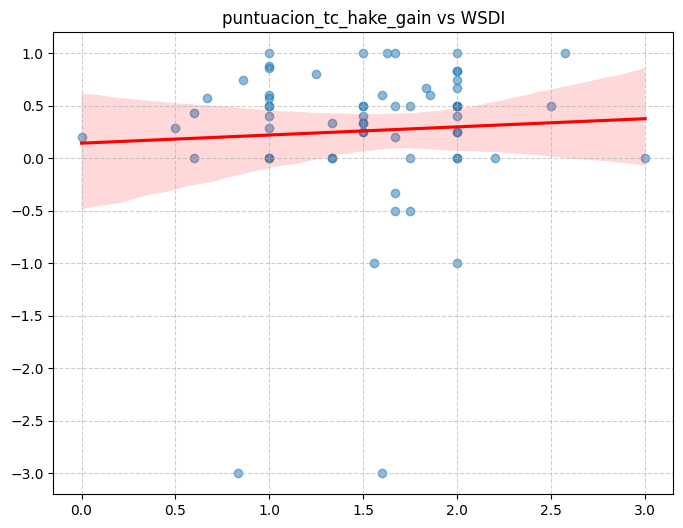

In [62]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=forms_interactions_df,  
    x='WSDI', 
    y='puntuacion_tc_hake_gain',
    scatter_kws={'alpha':0.5}, # Transparencia para ver puntos solapados
    line_kws={'color':'red'}   # Línea de tendencia
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

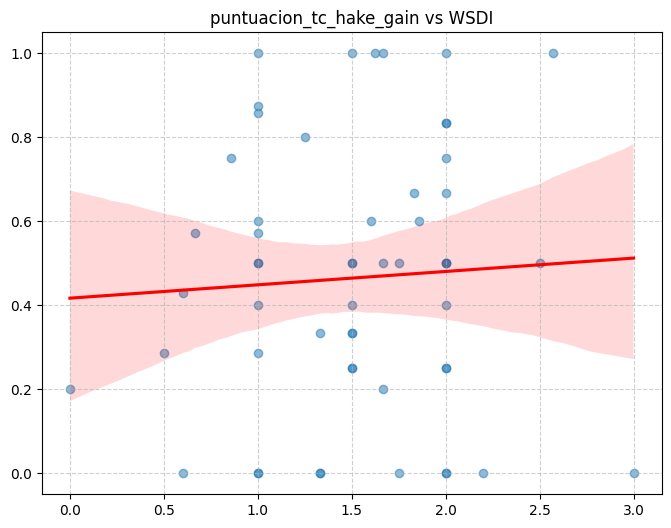

In [63]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=forms_interactions_df.filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    x='WSDI', 
    y='puntuacion_tc_hake_gain',
    scatter_kws={'alpha':0.5}, # Transparencia para ver puntos solapados
    line_kws={'color':'red'}   # Línea de tendencia
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

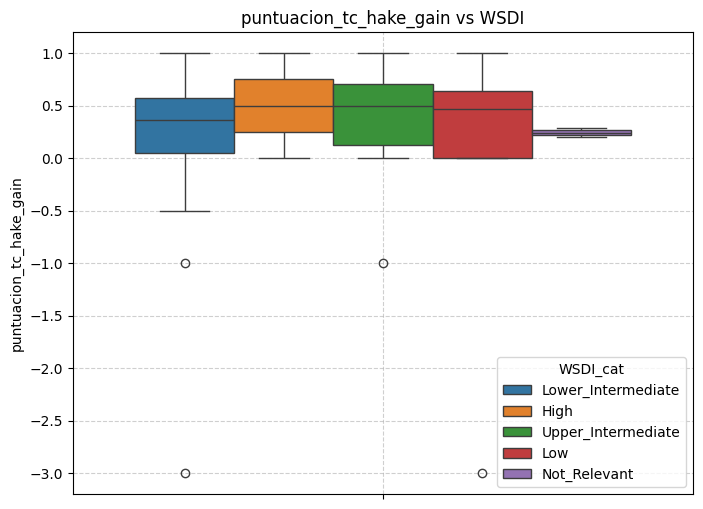

In [64]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

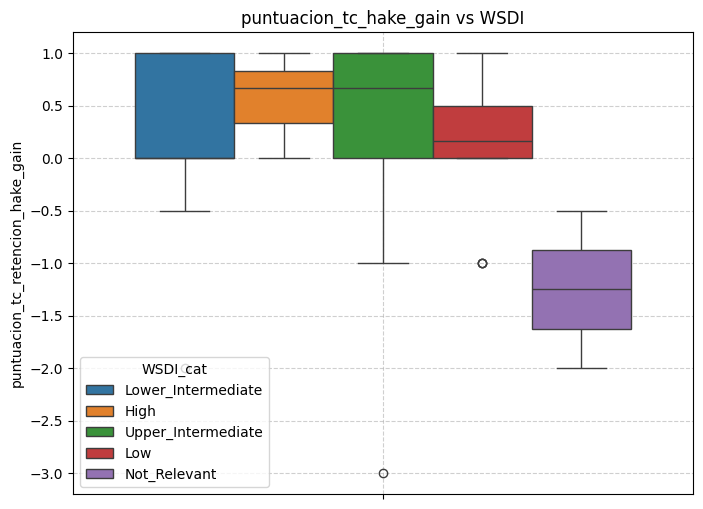

In [70]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_retencion_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

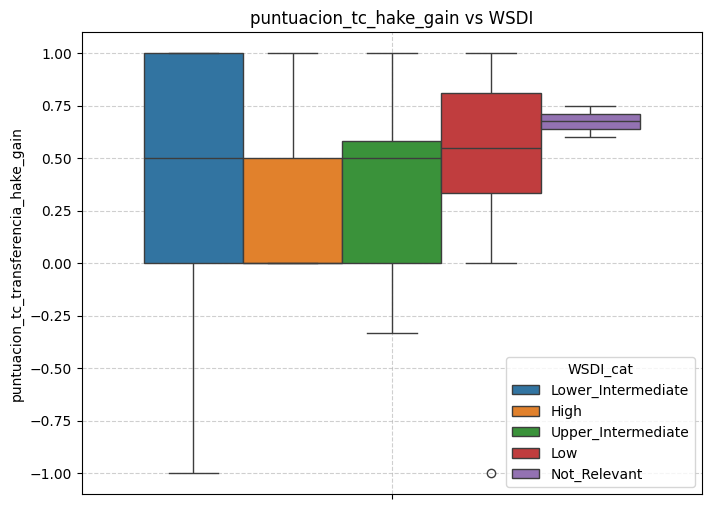

In [71]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_transferencia_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

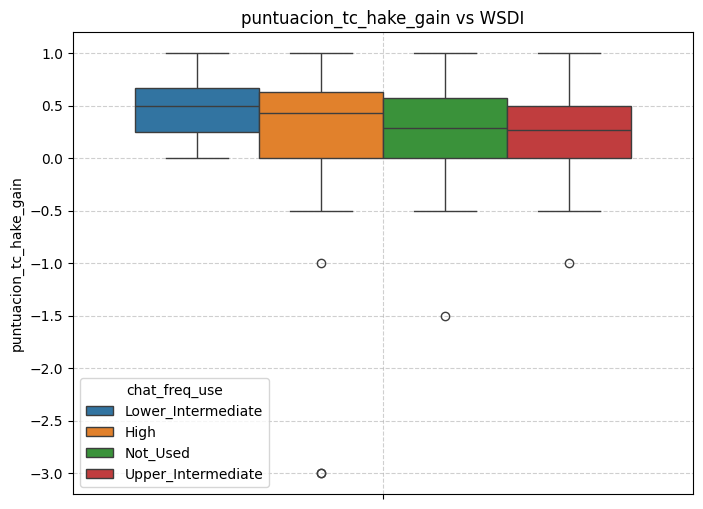

In [65]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df,  
    y='puntuacion_tc_hake_gain',
    hue='chat_freq_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

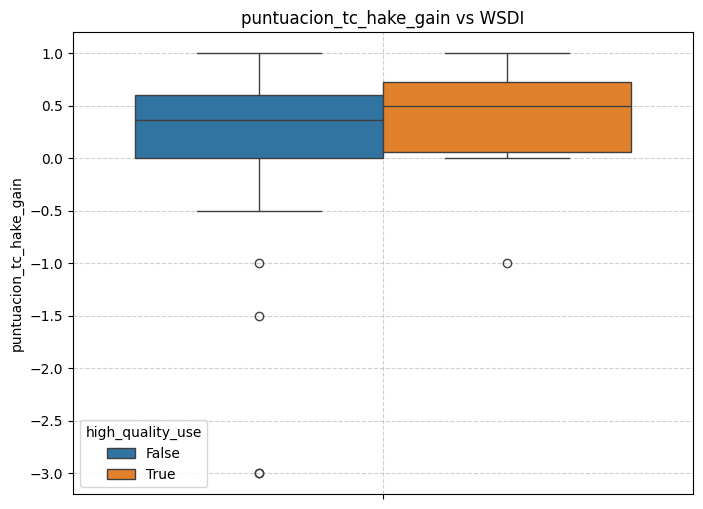

In [67]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('high_quality_use').is_not_null()),  
    y='puntuacion_tc_hake_gain',
    hue='high_quality_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

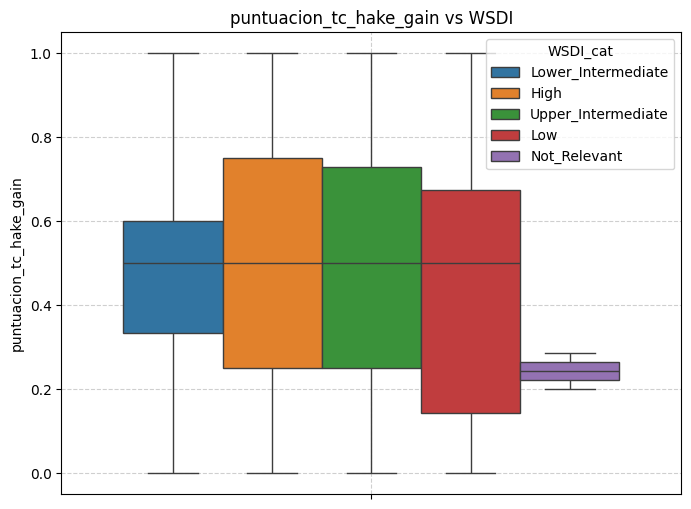

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    y='puntuacion_tc_hake_gain',
    hue='WSDI_cat',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

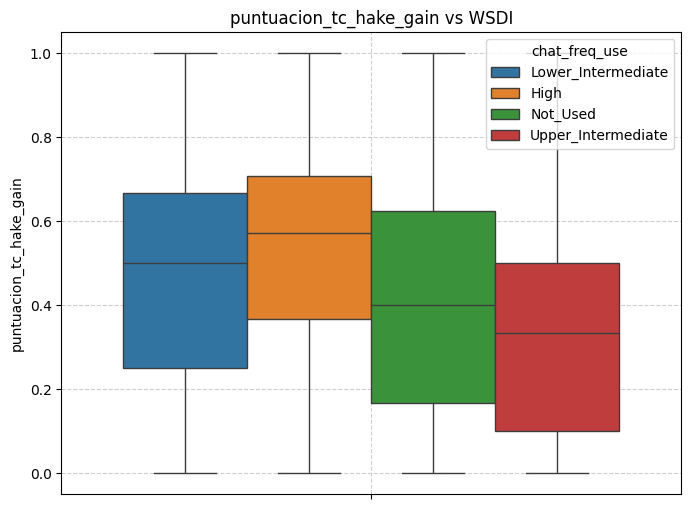

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    y='puntuacion_tc_hake_gain',
    hue='chat_freq_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

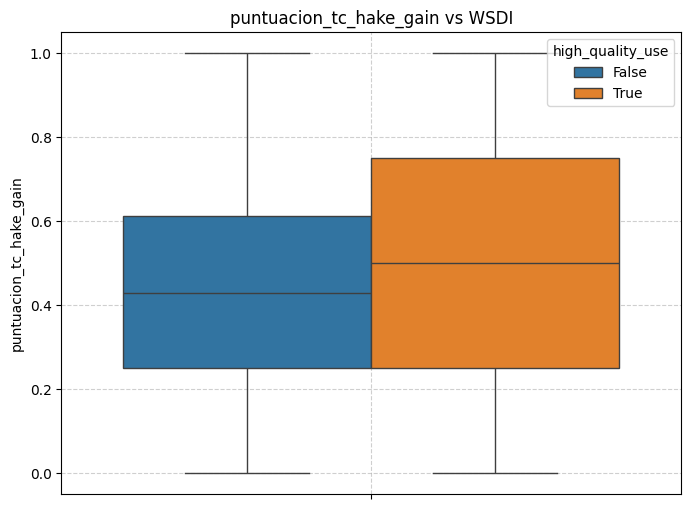

In [68]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=forms_interactions_df.filter(pl.col('high_quality_use').is_not_null()).filter(pl.col('puntuacion_tc_hake_gain') >= 0),  
    y='puntuacion_tc_hake_gain',
    hue='high_quality_use',
)

plt.title("puntuacion_tc_hake_gain vs WSDI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()